# **딥러닝 모델 설계도 (PyTorch 코드)**

# **딥러닝 모델 설계 코드**<br>
**입력 이미지를 받아 "이 숫자는 0~9 중 무엇이다"라고 예측하는 3층 신경망입니다.**

100%|██████████| 9.91M/9.91M [00:00<00:00, 95.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 52.7MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 82.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.40MB/s]


학습을 시작합니다...
Epoch 1 [200/938] Loss: 0.4146
Epoch 1 [400/938] Loss: 0.1854
Epoch 1 [600/938] Loss: 0.1527
Epoch 1 [800/938] Loss: 0.1372
Epoch 2 [200/938] Loss: 0.0891
Epoch 2 [400/938] Loss: 0.1021
Epoch 2 [600/938] Loss: 0.0824
Epoch 2 [800/938] Loss: 0.0763
Epoch 3 [200/938] Loss: 0.0543
Epoch 3 [400/938] Loss: 0.0651
Epoch 3 [600/938] Loss: 0.0640
Epoch 3 [800/938] Loss: 0.0575

[최종 결과] 테스트 데이터 정확도: 97.74%


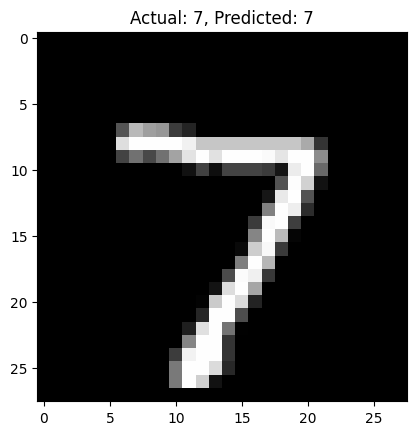

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ==========================================
# 1. 데이터 전처리 및 로드 (Data Preparation)
# ==========================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 데이터셋 다운로드
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 데이터 로더 (배치 설정)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# ==========================================
# 2. 모델 정의 (Model Architecture)
# ==========================================
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        # 입력: 784(28x28) -> 은닉1: 512 -> 은닉2: 256 -> 출력: 10
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        # 이미지를 1차원으로 펼치기
        x = x.view(-1, 28 * 28)
        # 활성화 함수 적용
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # 마지막 층은 점수(Logits) 출력
        x = self.fc3(x)
        return x

model = SimpleNet()

# ==========================================
# 3. 학습 준비 (Loss & Optimizer)
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 4. 학습 루프 (Training Loop)
# ==========================================
epochs = 3 # 3번 반복 학습
model.train()

print("학습을 시작합니다...")
for epoch in range(epochs):
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()         # 1) 기울기 초기화
        output = model(data)          # 2) 예측 (순전파)
        loss = criterion(output, target) # 3) 손실 계산
        loss.backward()               # 4) 역전파 (기울기 계산)
        optimizer.step()              # 5) 가중치 업데이트

        running_loss += loss.item()

        if batch_idx % 200 == 199:    # 200 배치마다 로그 출력
            print(f"Epoch {epoch+1} [{batch_idx+1}/{len(train_loader)}] Loss: {running_loss/200:.4f}")
            running_loss = 0.0

# ==========================================
# 5. 모델 평가 (Evaluation)
# ==========================================
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\n[최종 결과] 테스트 데이터 정확도: {100 * correct / total:.2f}%")

# ==========================================
# 6. 예측 결과 시각화 (Visualization)
# ==========================================
images, labels = next(iter(test_loader))
test_image = images[0]
test_label = labels[0]

with torch.no_grad():
    output = model(test_image.unsqueeze(0))
    _, predicted = torch.max(output, 1)

plt.imshow(test_image.squeeze(), cmap='gray')
plt.title(f"Actual: {test_label}, Predicted: {predicted.item()}")
plt.show()

In [ ]:
# 모델의 가중치만 파일로 저장 (파일명: mnist_model.pth)
#torch.save(model.state_dict(), 'mnist_model.pth')

# 나중에 불러올 때
# model.load_state_dict(torch.load('mnist_model.pth'))